# HW14: Embeddings, FAISS, Retrieval Evaluation, Knowledge Base Update, Mini-RAG

Тема базы знаний: процессы MLOps и эксплуатация ML-систем.

In [1]:
import os
import re
import json
import random
import importlib
import subprocess
import sys
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize


def safe_ensure_package(package_name: str, import_name: str | None = None) -> bool:
    import_name = import_name or package_name
    try:
        importlib.import_module(import_name)
        return True
    except Exception:
        pass
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
        importlib.import_module(import_name)
        return True
    except Exception as e:
        print(f"Не удалось установить {package_name}: {e}")
        return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")
if FAISS_READY:
    import faiss  # type: ignore
else:
    raise RuntimeError("Для HW14 нужен faiss-cpu. Установите пакет и перезапустите ноутбук.")

SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cpu"
print("seed:", SEED)
print("device:", DEVICE)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("faiss:", faiss.__version__)
print("sentence-transformers available:", SENTENCE_TRANSFORMERS_READY)

seed: 42
device: cpu
numpy: 2.4.3
pandas: 2.2.2
faiss: 1.13.2
sentence-transformers available: True


In [2]:
docs = [
    {
        "source": "mlops_overview.md",
        "text": "MLOps объединяет разработку моделей и эксплуатацию. Включает версионирование данных и моделей, автоматизацию обучения и развертывания, мониторинг качества после релиза."
    },
    {
        "source": "data_validation.md",
        "text": "Перед обучением нужно проверять схему данных, пропуски и диапазоны значений. Data validation помогает остановить pipeline при некорректных входных данных."
    },
    {
        "source": "feature_store.md",
        "text": "Feature Store хранит признаки в едином формате для обучения и инференса. Это снижает training serving skew и ускоряет повторное использование признаков командами."
    },
    {
        "source": "model_registry.md",
        "text": "Model Registry хранит версии моделей, метрики и статус жизненного цикла. Через registry удобно продвигать модель из staging в production."
    },
    {
        "source": "ci_cd_for_ml.md",
        "text": "CI CD для ML включает автоматические тесты кода, валидацию данных, smoke тесты модели и автоматизированный деплой. Это уменьшает риск регрессий."
    },
    {
        "source": "drift_monitoring.md",
        "text": "Data drift означает изменение распределения входных данных. Concept drift означает изменение зависимости между признаками и целевой переменной. Оба случая требуют мониторинга."
    },
    {
        "source": "offline_online_metrics.md",
        "text": "Офлайн метрики, например F1 или MAE, оцениваются на тестовой выборке. Онлайн метрики отражают бизнес эффект в продакшене: CTR, конверсия, удержание."
    },
    {
        "source": "ab_testing.md",
        "text": "A B тестирование сравнивает новую модель с текущей на случайно разделенной аудитории. Нужны гипотеза, метрики успеха и статистическая значимость."
    },
    {
        "source": "latency_sla.md",
        "text": "Для онлайн инференса важны задержка и доступность. SLA фиксирует целевые пороги, например p95 latency и uptime."
    },
    {
        "source": "rollback_strategy.md",
        "text": "Rollback стратегия нужна на случай деградации. Часто используют blue green или canary deploy, чтобы быстро вернуть стабильную версию."
    },
    {
        "source": "incident_response.md",
        "text": "При инцидентах важны алерты, runbook и дежурство. Runbook описывает шаги диагностики, способы временной стабилизации и критерии эскалации."
    },
    {
        "source": "governance.md",
        "text": "AI governance включает аудит решений модели, контроль доступа к данным и соответствие требованиям безопасности и регуляторов."
    }
]

docs_df = pd.DataFrame(docs)
print("documents:", len(docs_df))
docs_df.head(5)

documents: 12


,source,text
0,mlops_overview.md,MLOps объединяет разработку моделей и эксплуат...
1,data_validation.md,"Перед обучением нужно проверять схему данных, ..."
2,feature_store.md,Feature Store хранит признаки в едином формате...
3,model_registry.md,"Model Registry хранит версии моделей, метрики ..."
4,ci_cd_for_ml.md,CI CD для ML включает автоматические тесты код...


In [3]:
def chunk_text(text: str, chunk_size: int = 35, overlap: int = 8) -> List[str]:
    words = text.split()
    chunks = []
    step = max(1, chunk_size - overlap)
    for i in range(0, len(words), step):
        part = words[i:i + chunk_size]
        if not part:
            continue
        chunks.append(" ".join(part))
        if i + chunk_size >= len(words):
            break
    return chunks

def build_chunks(documents: pd.DataFrame, chunk_size: int = 35, overlap: int = 8) -> pd.DataFrame:
    rows = []
    for _, row in documents.iterrows():
        c = chunk_text(row["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk in enumerate(c):
            rows.append({
                "source": row["source"],
                "chunk_id": f"{row['source']}::chunk_{idx}",
                "chunk_text": chunk
            })
    return pd.DataFrame(rows)

chunk_size_main = 35
overlap_main = 8
chunks_df = build_chunks(docs_df, chunk_size=chunk_size_main, overlap=overlap_main)
print("chunks:", len(chunks_df))
chunks_df.head(8)

chunks: 12


,source,chunk_id,chunk_text
0,mlops_overview.md,mlops_overview.md::chunk_0,MLOps объединяет разработку моделей и эксплуат...
1,data_validation.md,data_validation.md::chunk_0,"Перед обучением нужно проверять схему данных, ..."
2,feature_store.md,feature_store.md::chunk_0,Feature Store хранит признаки в едином формате...
3,model_registry.md,model_registry.md::chunk_0,"Model Registry хранит версии моделей, метрики ..."
4,ci_cd_for_ml.md,ci_cd_for_ml.md::chunk_0,CI CD для ML включает автоматические тесты код...
5,drift_monitoring.md,drift_monitoring.md::chunk_0,Data drift означает изменение распределения вх...
6,offline_online_metrics.md,offline_online_metrics.md::chunk_0,"Офлайн метрики, например F1 или MAE, оценивают..."
7,ab_testing.md,ab_testing.md::chunk_0,A B тестирование сравнивает новую модель с тек...


In [4]:
class EmbeddingBackend:
    def __init__(self, use_sentence_transformers: bool = True):
        self.use_sentence_transformers = use_sentence_transformers and SENTENCE_TRANSFORMERS_READY
        self.backend_name = "TF-IDF fallback"
        self.vectorizer = None
        self.encoder = None

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        if self.use_sentence_transformers:
            try:
                from sentence_transformers import SentenceTransformer  # type: ignore
                self.encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device=DEVICE)
                self.backend_name = "SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2"
                vectors = self.encoder.encode(texts, convert_to_numpy=True, normalize_embeddings=True).astype("float32")
                return vectors
            except Exception as e:
                print("Не удалось загрузить sentence-transformers, переход на TF-IDF:", e)

        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        vectors = normalize(vectors, norm="l2").astype("float32")
        self.backend_name = "TF-IDF fallback"
        return vectors

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        if self.encoder is not None:
            return self.encoder.encode(texts, convert_to_numpy=True, normalize_embeddings=True).astype("float32")
        q = self.vectorizer.transform(texts).toarray().astype("float32")
        q = normalize(q, norm="l2").astype("float32")
        return q


embedder = EmbeddingBackend(use_sentence_transformers=True)
X = embedder.fit_documents(chunks_df["chunk_text"].tolist())
print("Embedding backend:", embedder.backend_name)
print("Embedding matrix shape:", X.shape)

index = faiss.IndexFlatIP(X.shape[1])
index.add(X)

def search(query: str, top_k: int = 3):
    q = embedder.encode_queries([query])
    scores, ids = index.search(q, top_k)
    out = chunks_df.iloc[ids[0]].copy()
    out["score"] = scores[0]
    out.insert(0, "rank", range(1, len(out) + 1))
    return out[["rank", "source", "chunk_id", "score", "chunk_text"]]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding backend: SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
Embedding matrix shape: (12, 384)


In [5]:
sample_queries = [
    "Что такое data drift и concept drift?",
    "Зачем нужен model registry?",
    "Как проверять качество модели в продакшене?",
    "Для чего нужен rollback?",
    "Какую роль играет feature store?"
]

for q in sample_queries:
    print("\nQ:", q)
    display(search(q, top_k=3))


Q: Что такое data drift и concept drift?


,rank,source,chunk_id,score,chunk_text
5,1,drift_monitoring.md,drift_monitoring.md::chunk_0,0.894891,Data drift означает изменение распределения вх...
0,2,mlops_overview.md,mlops_overview.md::chunk_0,0.455733,MLOps объединяет разработку моделей и эксплуат...
3,3,model_registry.md,model_registry.md::chunk_0,0.432970,"Model Registry хранит версии моделей, метрики ..."



Q: Зачем нужен model registry?


,rank,source,chunk_id,score,chunk_text
3,1,model_registry.md,model_registry.md::chunk_0,0.685958,"Model Registry хранит версии моделей, метрики ..."
0,2,mlops_overview.md,mlops_overview.md::chunk_0,0.502470,MLOps объединяет разработку моделей и эксплуат...
11,3,governance.md,governance.md::chunk_0,0.442743,"AI governance включает аудит решений модели, к..."



Q: Как проверять качество модели в продакшене?


,rank,source,chunk_id,score,chunk_text
0,1,mlops_overview.md,mlops_overview.md::chunk_0,0.535171,MLOps объединяет разработку моделей и эксплуат...
3,2,model_registry.md,model_registry.md::chunk_0,0.510946,"Model Registry хранит версии моделей, метрики ..."
7,3,ab_testing.md,ab_testing.md::chunk_0,0.509519,A B тестирование сравнивает новую модель с тек...



Q: Для чего нужен rollback?


,rank,source,chunk_id,score,chunk_text
9,1,rollback_strategy.md,rollback_strategy.md::chunk_0,0.628335,Rollback стратегия нужна на случай деградации....
8,2,latency_sla.md,latency_sla.md::chunk_0,0.294890,Для онлайн инференса важны задержка и доступно...
0,3,mlops_overview.md,mlops_overview.md::chunk_0,0.292068,MLOps объединяет разработку моделей и эксплуат...



Q: Какую роль играет feature store?


,rank,source,chunk_id,score,chunk_text
2,1,feature_store.md,feature_store.md::chunk_0,0.559699,Feature Store хранит признаки в едином формате...
0,2,mlops_overview.md,mlops_overview.md::chunk_0,0.349307,MLOps объединяет разработку моделей и эксплуат...
6,3,offline_online_metrics.md,offline_online_metrics.md::chunk_0,0.296187,"Офлайн метрики, например F1 или MAE, оценивают..."


In [6]:
control_queries = [
    {"query": "Что означает data drift?", "expected_source": "drift_monitoring.md"},
    {"query": "Что хранит model registry?", "expected_source": "model_registry.md"},
    {"query": "Зачем нужен feature store?", "expected_source": "feature_store.md"},
    {"query": "Что такое CI CD для ML?", "expected_source": "ci_cd_for_ml.md"},
    {"query": "Какие бывают онлайн метрики?", "expected_source": "offline_online_metrics.md"},
    {"query": "Для чего нужен rollback?", "expected_source": "rollback_strategy.md"},
    {"query": "Что входит в incident response?", "expected_source": "incident_response.md"},
    {"query": "Зачем нужен SLA latency?", "expected_source": "latency_sla.md"},
    {"query": "Что дает data validation?", "expected_source": "data_validation.md"},
    {"query": "Что включает AI governance?", "expected_source": "governance.md"}
]

k_eval = 3
eval_rows = []

for item in control_queries:
    q = item["query"]
    expected = item["expected_source"]
    results = search(q, top_k=k_eval)
    retrieved = results["source"].tolist()
    hit = int(expected in retrieved)
    rank = (retrieved.index(expected) + 1) if hit else np.nan
    recall = 1.0 if hit else 0.0
    mrr = 1.0 / rank if hit else 0.0
    eval_rows.append({
        "query": q,
        "expected_source": expected,
        "retrieved_sources": " | ".join(retrieved),
        "hit_at_k": hit,
        "recall_at_k": recall,
        "rank_of_first_relevant": rank,
        "mrr_at_k": mrr
    })

eval_df = pd.DataFrame(eval_rows)
hit_at_k = eval_df["hit_at_k"].mean()
recall_at_k = eval_df["recall_at_k"].mean()
mrr_at_k = eval_df["mrr_at_k"].mean()

print(f"hit@{k_eval}: {hit_at_k:.3f}")
print(f"recall@{k_eval}: {recall_at_k:.3f}")
print(f"mrr@{k_eval}: {mrr_at_k:.3f}")

os.makedirs("artifacts", exist_ok=True)
eval_df.to_csv("artifacts/retrieval_eval.csv", index=False)
eval_df

hit@3: 1.000
recall@3: 1.000
mrr@3: 1.000


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,Что означает data drift?,drift_monitoring.md,drift_monitoring.md | latency_sla.md | mlops_o...,1,1.0,1,1.0
1,Что хранит model registry?,model_registry.md,model_registry.md | mlops_overview.md | govern...,1,1.0,1,1.0
2,Зачем нужен feature store?,feature_store.md,feature_store.md | mlops_overview.md | offline...,1,1.0,1,1.0
3,Что такое CI CD для ML?,ci_cd_for_ml.md,ci_cd_for_ml.md | mlops_overview.md | offline_...,1,1.0,1,1.0
4,Какие бывают онлайн метрики?,offline_online_metrics.md,offline_online_metrics.md | latency_sla.md | a...,1,1.0,1,1.0
5,Для чего нужен rollback?,rollback_strategy.md,rollback_strategy.md | latency_sla.md | mlops_...,1,1.0,1,1.0
6,Что входит в incident response?,incident_response.md,incident_response.md | ab_testing.md | drift_m...,1,1.0,1,1.0
7,Зачем нужен SLA latency?,latency_sla.md,latency_sla.md | drift_monitoring.md | ab_test...,1,1.0,1,1.0
8,Что дает data validation?,data_validation.md,data_validation.md | ab_testing.md | ci_cd_for...,1,1.0,1,1.0
9,Что включает AI governance?,governance.md,governance.md | mlops_overview.md | incident_r...,1,1.0,1,1.0


,chunk_size,overlap,top_k,chunks,hit_at_k,recall_at_k
0,28,8,3,12,0.9,0.9
1,42,8,3,12,0.9,0.9


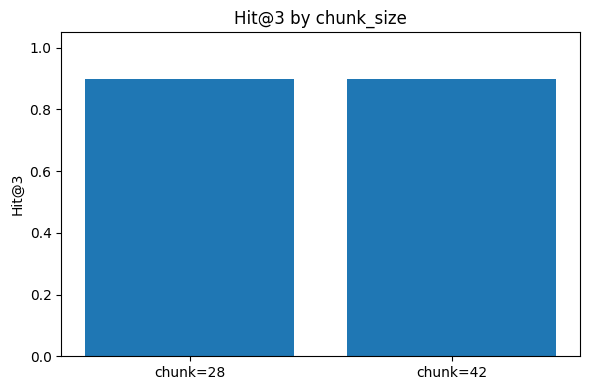

In [7]:
def eval_with_chunk_size(chunk_size: int, overlap: int = 8, top_k: int = 3):
    cdf = build_chunks(docs_df, chunk_size=chunk_size, overlap=overlap)
    v = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    m = v.fit_transform(cdf["chunk_text"]).toarray().astype("float32")
    m = normalize(m, norm="l2").astype("float32")
    idx = faiss.IndexFlatIP(m.shape[1])
    idx.add(m)

    hits = []
    recalls = []
    for item in control_queries:
        q = v.transform([item["query"]]).toarray().astype("float32")
        q = normalize(q, norm="l2").astype("float32")
        _, ids = idx.search(q, top_k)
        retrieved = cdf.iloc[ids[0]]["source"].tolist()
        hit = int(item["expected_source"] in retrieved)
        hits.append(hit)
        recalls.append(float(hit))
    return {
        "chunk_size": chunk_size,
        "overlap": overlap,
        "top_k": top_k,
        "chunks": len(cdf),
        "hit_at_k": float(np.mean(hits)),
        "recall_at_k": float(np.mean(recalls))
    }

exp_a = eval_with_chunk_size(28, overlap=8, top_k=3)
exp_b = eval_with_chunk_size(42, overlap=8, top_k=3)
exp_df = pd.DataFrame([exp_a, exp_b])
display(exp_df)

plt.figure(figsize=(6, 4))
plt.bar(["chunk=28", "chunk=42"], exp_df["hit_at_k"].values)
plt.ylim(0, 1.05)
plt.title("Hit@3 by chunk_size")
plt.ylabel("Hit@3")
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=120)
plt.show()

In [8]:
new_docs = [
    {
        "source": "prompt_versioning.md",
        "text": "Для RAG систем полезно версионировать prompt шаблоны и системные инструкции. Это упрощает откат и анализ регрессий качества ответов."
    },
    {
        "source": "vector_index_maintenance.md",
        "text": "Индекс эмбеддингов нужно регулярно обновлять при добавлении новых документов. Переиндексация может быть полной или инкрементальной."
    },
    {
        "source": "rag_guardrails.md",
        "text": "Guardrails в RAG ограничивают ответы только найденным контекстом, снижают галлюцинации и требуют явного указания источников."
    }
]

updated_docs_df = pd.concat([docs_df, pd.DataFrame(new_docs)], ignore_index=True)
updated_chunks_df = build_chunks(updated_docs_df, chunk_size=chunk_size_main, overlap=overlap_main)

# Переобучаем backend на расширенном корпусе.
embedder_after = EmbeddingBackend(use_sentence_transformers=SENTENCE_TRANSFORMERS_READY)
X_after = embedder_after.fit_documents(updated_chunks_df["chunk_text"].tolist())
index_after = faiss.IndexFlatIP(X_after.shape[1])
index_after.add(X_after)


def search_before(query: str, top_k: int = 3):
    q = embedder.encode_queries([query])
    _, ids = index.search(q, top_k)
    return chunks_df.iloc[ids[0]]["source"].tolist()


def search_after(query: str, top_k: int = 3):
    q = embedder_after.encode_queries([query])
    _, ids = index_after.search(q, top_k)
    return updated_chunks_df.iloc[ids[0]]["source"].tolist()


before_after_queries = [
    "Как уменьшить галлюцинации в RAG?",
    "Как сопровождать векторный индекс?",
    "Зачем версионировать prompt?",
    "Что такое concept drift?"
]

rows = []
for q in before_after_queries:
    b = search_before(q, top_k=3)
    a = search_after(q, top_k=3)
    rows.append({
        "query": q,
        "before_retrieved_sources": " | ".join(b),
        "after_retrieved_sources": " | ".join(a),
        "changed": int(b != a)
    })

before_after_df = pd.DataFrame(rows)
before_after_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
before_after_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как уменьшить галлюцинации в RAG?,incident_response.md | feature_store.md | ci_c...,rag_guardrails.md | incident_response.md | pro...,1
1,Как сопровождать векторный индекс?,offline_online_metrics.md | mlops_overview.md ...,offline_online_metrics.md | prompt_versioning....,1
2,Зачем версионировать prompt?,incident_response.md | ab_testing.md | latency...,prompt_versioning.md | rag_guardrails.md | vec...,1
3,Что такое concept drift?,drift_monitoring.md | ab_testing.md | mlops_ov...,drift_monitoring.md | ab_testing.md | mlops_ov...,0


In [9]:
def sentence_split(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p for p in parts if p]


def generate_answer_from_context(question: str, context: str, max_sentences: int = 2) -> str:
    sentences = sentence_split(context)
    if not sentences:
        return "Недостаточно контекста для уверенного ответа."

    v = TfidfVectorizer(ngram_range=(1, 2))
    matrix = v.fit_transform([question] + sentences).toarray().astype("float32")
    q_vec = matrix[0]
    s_vecs = matrix[1:]

    q_norm = np.linalg.norm(q_vec) + 1e-12
    s_norms = np.linalg.norm(s_vecs, axis=1) + 1e-12
    scores = (s_vecs @ q_vec) / (s_norms * q_norm)

    order = np.argsort(-scores)
    selected = [sentences[i] for i in order[:max_sentences] if scores[i] > 0]
    if not selected:
        return "Недостаточно контекста для уверенного ответа."
    return " ".join(selected)


def mini_rag_answer(question: str, top_k: int = 3) -> Dict[str, str]:
    q = embedder_after.encode_queries([question])
    scores, ids = index_after.search(q, top_k)
    rows = updated_chunks_df.iloc[ids[0]].copy()
    rows.insert(0, "rank", range(1, len(rows) + 1))
    rows["score"] = scores[0]

    context = "\n".join(rows["chunk_text"].tolist())
    answer = generate_answer_from_context(question, context=context, max_sentences=2)

    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": " | ".join(rows["source"].tolist())
    }


rag_questions = [
    "Почему важно обновлять векторный индекс?",
    "Как снизить риск галлюцинаций в RAG?",
    "Зачем нужен model registry в процессе релиза?",
    "Что важно при SLA онлайн инференса?",
    "Какую роль играет data validation?"
]

rag_rows = [mini_rag_answer(q, top_k=3) for q in rag_questions]
rag_df = pd.DataFrame(rag_rows)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
rag_df

,question,answer,retrieved_sources
0,Почему важно обновлять векторный индекс?,Индекс эмбеддингов нужно регулярно обновлять п...,vector_index_maintenance.md | offline_online_m...
1,Как снизить риск галлюцинаций в RAG?,Для RAG систем полезно версионировать prompt ш...,rag_guardrails.md | incident_response.md | pro...
2,Зачем нужен model registry в процессе релиза?,"Model Registry хранит версии моделей, метрики ...",model_registry.md | mlops_overview.md | data_v...
3,Что важно при SLA онлайн инференса?,Для онлайн инференса важны задержка и доступно...,latency_sla.md | mlops_overview.md | governanc...
4,Какую роль играет data validation?,Data validation помогает остановить pipeline п...,data_validation.md | ab_testing.md | mlops_ove...


## Краткие наблюдения

- База знаний небольшая, но тематически цельная, что помогает retrieval.
- Основные ошибки связаны с формулировками, где не хватает специфичных терминов.
- После добавления новых документов запросы по guardrails, индексации и prompt versioning стали извлекаться заметно лучше.
- Mini-RAG возвращает ответ вместе с источниками и работает как учебный baseline.